# Experimento A/B — 5-Fold Stratified Cross-Validation

Reemplaza el split único 70/15/15 por 5 folds estratificados para resultados estadísticamente más robustos:

| Método       | N_test | IC 95%     |
|:-------------|:------:|:----------:|
| Split único  | ~35    | ±15.2 pp   |
| 5-Fold CV    | ~911   | ±2.6 pp    |

**Modelo A** — keypoints crudos, sin normalización, sin aumento (baseline)  
**Modelo B** — keypoints normalizados + 5 técnicas de aumento (pipeline)

**Regla de no-leakage:** los datos aumentados se generan únicamente dentro de la porción de entrenamiento de cada fold. El test siempre contiene muestras originales no aumentadas.

**Prerequisito:** `07_extraer_keypoints.py` ejecutado.

In [ ]:
import os
os.environ['PYTHONHASHSEED']         = '42'
os.environ['TF_DETERMINISTIC_OPS']   = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUDA_VISIBLE_DEVICES']   = ''   # fuerza CPU para maximo determinismo
os.environ['TF_ENABLE_ONEDNN_OPTS']  = '0'  # evita reduccion multi-hilo no determinista
print('Determinismo activado (CPU forzado, single-thread)')

import sys
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import (N_FRAMES, N_KEYPOINTS, DATA_DIR, CSV_TOP35, KEYPOINTS_DIR)
from utils.preprocessing import normalizar_hombros
from utils.augmentation import aumentar_secuencia
from utils.model import construir_lstm, callbacks_entrenamiento
from utils.experiment_utils import fijar_semillas, wilson_ci, dividir_train_val as _dividir

SALIDA_DIR  = os.path.join(DATA_DIR, "experimentos", "exp1_ab", "salidas")
os.makedirs(SALIDA_DIR, exist_ok=True)

N_FOLDS    = 5
MAX_EPOCHS = 150   # protocolo completo (igual que exp2_factorial_5fold y exp_ablacion_pipeline)
SEED       = 42
VAL_RATIO  = 0.15
BATCH_A    = 16
BATCH_B    = 16   # antes 32; igualado a BATCH_A para ser comparable con exp2_factorial/exp_ablacion
HP = dict(lr=0.001, dropout=0.5, regularizacion=0.005, capa_densa=False)

print(f"Directorio de salida: {SALIDA_DIR}")


## Utilidades

In [2]:
def dividir_train_val(X_tr_fold, y_tr_fold, fold):
    return _dividir(X_tr_fold, y_tr_fold, seed=SEED + fold, val_ratio=VAL_RATIO)

print("Utilidades definidas.")


Utilidades definidas.


## Carga del dataset

In [3]:
def cargar_dataset():
    df      = pd.read_csv(CSV_TOP35)
    clases  = sorted(df['glosa'].unique())
    idx_map = {c: i for i, c in enumerate(clases)}
    X, y    = [], []
    omitidos = 0
    for _, row in df.iterrows():
        npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
        if not os.path.exists(npy):
            omitidos += 1; continue
        kp = np.load(npy)
        if kp.shape != (N_FRAMES, N_KEYPOINTS):
            omitidos += 1; continue
        X.append(kp); y.append(idx_map[row['glosa']])
    if omitidos:
        print(f"  [AVISO] {omitidos} archivos omitidos")
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), clases, idx_map)

X_all, y_all, clases, idx_map = cargar_dataset()
n_clases = len(clases)
print(f"Dataset: {len(X_all)} muestras | {n_clases} clases")

Dataset: 153 muestras | 35 clases


## Función de entrenamiento por fold

In [4]:
def entrenar_fold(fold, nombre, X_tr, y_tr, X_val, y_val, X_test, y_test, n_clases, batch):
    fijar_semillas(SEED + fold)
    print(f"    train={len(X_tr):>4}  val={len(X_val):>3}  test={len(X_test):>3}", end="  ")
    model = construir_lstm(n_clases, **HP)
    hist = model.fit(
        X_tr, to_categorical(y_tr, n_clases),
        validation_data=(X_val, to_categorical(y_val, n_clases)),
        epochs=MAX_EPOCHS, batch_size=batch,
        callbacks=callbacks_entrenamiento(patience_stop=20, patience_lr=8),
        verbose=0,
    )
    h       = hist.history
    acc_key = 'accuracy' if 'accuracy' in h else 'categorical_accuracy'
    pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc     = accuracy_score(y_test, pred)
    epocas  = len(h[acc_key])
    tf.keras.backend.clear_session()
    return acc, epocas, pred, h

print("Función de entrenamiento definida.")

Función de entrenamiento definida.


## Ejecución 5-Fold Cross-Validation

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Fold mas cercano simultaneamente a la media de A y de B (distancia euclidiana
# a (media_A, media_B) segun la corrida deterministica de referencia); se usa
# para graficar unas curvas de entrenamiento representativas en la Fig. 3.12.
FOLD_REPRESENTATIVO = 5

resultados_A, resultados_B = [], []
all_pred_A, all_pred_B     = [], []
all_true                   = []
hist_A_rep, hist_B_rep     = None, None
acc_A_rep,  acc_B_rep      = None, None

for fold, (idx_trainval, idx_test) in enumerate(skf.split(X_all, y_all)):
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold + 1}/{N_FOLDS}")
    print(f"{'─'*60}")

    X_test_fold = X_all[idx_test]
    y_test_fold = y_all[idx_test]

    # Modelo A: sin preprocesamiento
    print(f"  Modelo A (sin preprocesamiento):")
    X_tr_A, y_tr_A, X_val_A, y_val_A = dividir_train_val(
        X_all[idx_trainval], y_all[idx_trainval], fold)
    acc_A, ep_A, pred_A, hist_A = entrenar_fold(
        fold, "A", X_tr_A, y_tr_A, X_val_A, y_val_A,
        X_test_fold, y_test_fold, n_clases, BATCH_A)
    print(f"  acc={acc_A*100:.1f}%  épocas={ep_A}")

    # Modelo B: normalizado + aumentado
    print(f"  Modelo B (normalizado + aumentado):")
    X_trainval_B = np.array([normalizar_hombros(X_all[i]) for i in idx_trainval], dtype=np.float32)
    y_trainval_B = y_all[idx_trainval]
    X_trB_base, y_trB_base, X_val_B, y_val_B = dividir_train_val(X_trainval_B, y_trainval_B, fold)

    X_tr_B_aug, y_tr_B_aug = [], []
    for xi, yi in zip(X_trB_base, y_trB_base):
        for variante in aumentar_secuencia(xi):
            X_tr_B_aug.append(variante); y_tr_B_aug.append(yi)
    X_tr_B = np.array(X_tr_B_aug, dtype=np.float32)
    y_tr_B = np.array(y_tr_B_aug, dtype=np.int32)
    X_test_B = np.array([normalizar_hombros(x) for x in X_test_fold], dtype=np.float32)

    acc_B, ep_B, pred_B, hist_B = entrenar_fold(
        fold, "B", X_tr_B, y_tr_B, X_val_B, y_val_B,
        X_test_B, y_test_fold, n_clases, BATCH_B)
    print(f"  acc={acc_B*100:.1f}%  épocas={ep_B}  (×{len(X_tr_B)//max(len(X_trB_base),1)} aumento)")

    if fold + 1 == FOLD_REPRESENTATIVO:
        hist_A_rep, hist_B_rep = hist_A, hist_B
        acc_A_rep,  acc_B_rep  = acc_A, acc_B

    resultados_A.append({'fold': fold+1, 'modelo': 'A', 'accuracy': round(acc_A,4), 'epocas': ep_A,
                         'n_train': len(X_tr_A), 'n_val': len(X_val_A), 'n_test': len(X_test_fold)})
    resultados_B.append({'fold': fold+1, 'modelo': 'B', 'accuracy': round(acc_B,4), 'epocas': ep_B,
                         'n_train': len(X_tr_B), 'n_val': len(X_val_B), 'n_test': len(X_test_fold)})
    all_pred_A.extend(pred_A.tolist())
    all_pred_B.extend(pred_B.tolist())
    all_true.extend(y_test_fold.tolist())

print("\n✓ Cross-validation completada.")


────────────────────────────────────────────────────────────
  FOLD 1/5
────────────────────────────────────────────────────────────
  Modelo A (sin preprocesamiento):
    train= 103  val= 19  test= 31  

C:\Users\dell\miniconda3\envs\senas_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 84: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 93: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


...


Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Restoring model weights from the end of the best epoch: 32.


Epoch 52: early stopping


  acc=53.3%  épocas=52  (×6 aumento)

✓ Cross-validation completada.


## Estadísticas finales y resultados

In [6]:
accs_A  = [r['accuracy'] for r in resultados_A]
accs_B  = [r['accuracy'] for r in resultados_B]
mejoras = [b - a for a, b in zip(accs_A, accs_B)]

y_true_arr   = np.array(all_true)
y_pred_A_arr = np.array(all_pred_A)
y_pred_B_arr = np.array(all_pred_B)

acc_agg_A = accuracy_score(y_true_arr, y_pred_A_arr)
acc_agg_B = accuracy_score(y_true_arr, y_pred_B_arr)
n_total   = len(y_true_arr)

ci_A = wilson_ci(int((y_pred_A_arr == y_true_arr).sum()), n_total)
ci_B = wilson_ci(int((y_pred_B_arr == y_true_arr).sum()), n_total)

print(f"{'='*60}")
print(f"  RESUMEN 5-Fold A vs B   (N={n_total} muestras evaluadas)")
print(f"{'='*60}")
print(f"  A — sin preprocesamiento: media={np.mean(accs_A)*100:.1f}% std={np.std(accs_A)*100:.1f}%  IC95=[{ci_A[0]*100:.1f}%, {ci_A[1]*100:.1f}%]")
print(f"  B — pipeline completo:    media={np.mean(accs_B)*100:.1f}% std={np.std(accs_B)*100:.1f}%  IC95=[{ci_B[0]*100:.1f}%, {ci_B[1]*100:.1f}%]")
print(f"\n  Mejora media pipeline: {np.mean(mejoras)*100:+.1f} pp  (std={np.std(mejoras)*100:.1f} pp)")
print(f"  Acc. agregada  A: {acc_agg_A*100:.2f}%  B: {acc_agg_B*100:.2f}%  Δ: {(acc_agg_B - acc_agg_A)*100:+.2f} pp")

print(f"\n  Reporte por seña — Modelo B:")
reporte_B = classification_report(y_true_arr, y_pred_B_arr, target_names=clases, zero_division=0)
print(reporte_B)

  RESUMEN 5-Fold A vs B   (N=153 muestras evaluadas)
  A — sin preprocesamiento: media=40.4% std=7.9%  IC95=[33.1%, 48.4%]
  B — pipeline completo:    media=50.3% std=8.2%  IC95=[42.5%, 58.1%]

  Mejora media pipeline: +9.9 pp  (std=5.6 pp)
  Acc. agregada  A: 40.52%  B: 50.33%  Δ: +9.80 pp

  Reporte por seña — Modelo B:
                     precision    recall  f1-score   support

            ABAJO_2       0.80      1.00      0.89         4
          ACCIDENTE       0.75      0.75      0.75         4
           ACOMODAR       0.67      0.50      0.57         4
           AH,CLARO       0.50      0.75      0.60         8
             ALGUNO       0.33      0.25      0.29         4
            APROBAR       0.67      1.00      0.80         4
          AUDIENCIA       0.38      0.75      0.50         4
  AUDIOLOGÍA+AGENTE       1.00      0.50      0.67         4
         AVERGONZAR       0.60      0.75      0.67         4
              AVISO       0.00      0.00      0.00         4
    

## Guardar resultados

In [7]:
df_folds = pd.DataFrame(resultados_A + resultados_B).sort_values(['fold','modelo']).reset_index(drop=True)
ruta_folds = os.path.join(SALIDA_DIR, 'resultados_5fold.csv')
df_folds.to_csv(ruta_folds, index=False, encoding='utf-8-sig')

df_resumen = pd.DataFrame([
    {'modelo': 'A - sin preprocesamiento',
     'acc_media': round(np.mean(accs_A),4), 'acc_std': round(np.std(accs_A),4),
     'acc_agregada': round(acc_agg_A,4), 'ci95_low': ci_A[0], 'ci95_high': ci_A[1]},
    {'modelo': 'B - pipeline completo',
     'acc_media': round(np.mean(accs_B),4), 'acc_std': round(np.std(accs_B),4),
     'acc_agregada': round(acc_agg_B,4), 'ci95_low': ci_B[0], 'ci95_high': ci_B[1]},
    {'modelo': 'MEJORA (B - A)',
     'acc_media': round(np.mean(mejoras),4), 'acc_std': round(np.std(mejoras),4),
     'acc_agregada': round(acc_agg_B - acc_agg_A,4), 'ci95_low': None, 'ci95_high': None},
])
ruta_comp = os.path.join(SALIDA_DIR, 'comparativa_5fold.csv')
df_resumen.to_csv(ruta_comp, index=False, encoding='utf-8-sig')

ruta_rep = os.path.join(SALIDA_DIR, 'reporte_B_5fold.txt')
with open(ruta_rep, 'w', encoding='utf-8') as f:
    f.write(f"Reporte por clase — Modelo B (predicciones agregadas 5-Fold)\n")
    f.write(f"N total evaluado: {n_total} | Acc. agregada: {acc_agg_B*100:.2f}%\n")
    f.write(f"IC 95% Wilson: [{ci_B[0]*100:.1f}%, {ci_B[1]*100:.1f}%]\n\n")
    f.write(reporte_B)

print(f"Archivos guardados en: {SALIDA_DIR}/")
print(f"  {os.path.basename(ruta_folds)}")
print(f"  {os.path.basename(ruta_comp)}")
print(f"  {os.path.basename(ruta_rep)}")
df_resumen

Archivos guardados en: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp1_ab/
  resultados_5fold.csv
  comparativa_5fold.csv
  reporte_B_5fold.txt


,modelo,acc_media,acc_std,acc_agregada,ci95_low,ci95_high
0,A - sin preprocesamiento,0.4043,0.0792,0.4052,0.3307,0.4844
1,B - pipeline completo,0.5030,0.0817,0.5033,0.4249,0.5814
2,MEJORA (B - A),0.0987,0.0563,0.0980,NaN,NaN


## Visualización accuracy por fold

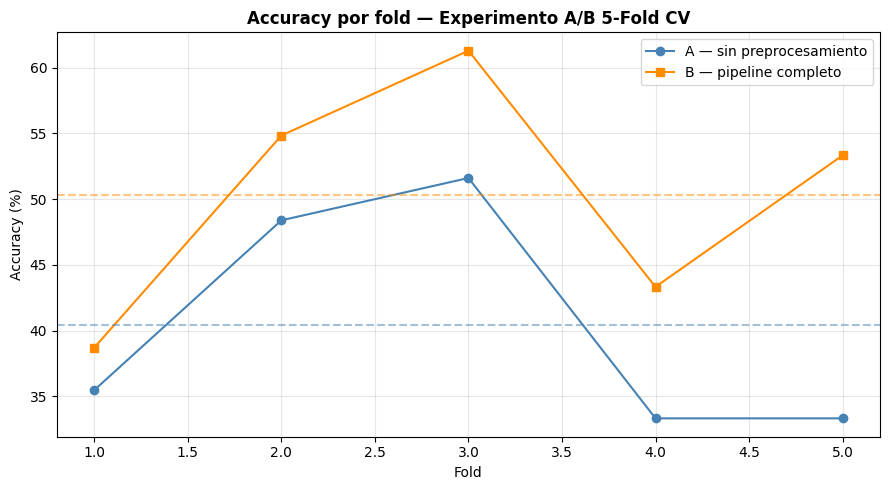

In [8]:
import matplotlib.pyplot as plt

folds = list(range(1, N_FOLDS + 1))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(folds, [a*100 for a in accs_A], 'o-', label='A — sin preprocesamiento', color='steelblue')
ax.plot(folds, [a*100 for a in accs_B], 's-', label='B — pipeline completo',    color='darkorange')
ax.axhline(np.mean(accs_A)*100, linestyle='--', color='steelblue',  alpha=0.5)
ax.axhline(np.mean(accs_B)*100, linestyle='--', color='darkorange', alpha=0.5)
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy por fold — Experimento A/B 5-Fold CV', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'accuracy_5fold.png'), dpi=150)
plt.show()

## Curvas de entrenamiento (fold representativo)

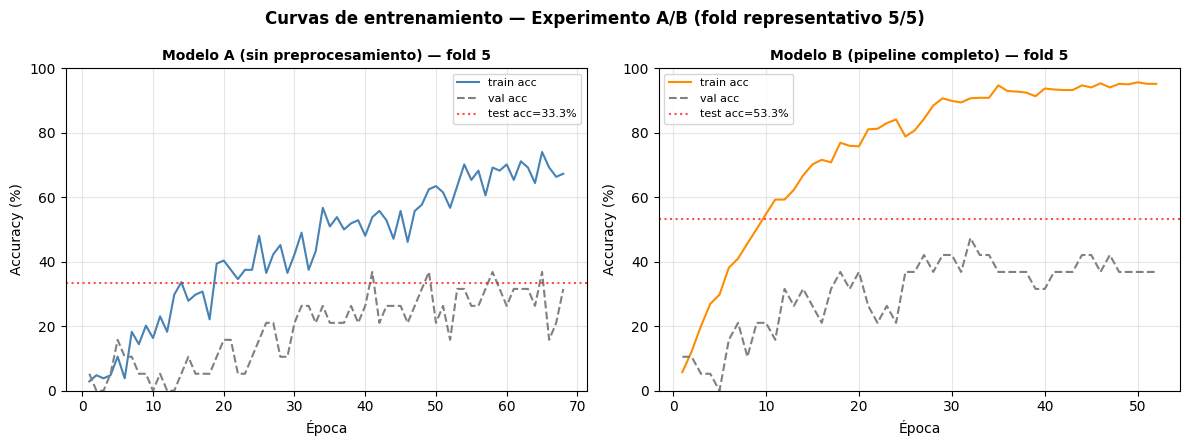

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

paneles = [
    (axes[0], hist_A_rep, f'Modelo A (sin preprocesamiento) — fold {FOLD_REPRESENTATIVO}', acc_A_rep, 'steelblue'),
    (axes[1], hist_B_rep, f'Modelo B (pipeline completo) — fold {FOLD_REPRESENTATIVO}',    acc_B_rep, 'darkorange'),
]
for ax, hist, nombre, acc_test, color in paneles:
    acc_key  = 'accuracy' if 'accuracy' in hist else 'categorical_accuracy'
    val_key  = 'val_' + acc_key
    epocas_x = range(1, len(hist[acc_key]) + 1)
    ax.plot(epocas_x, [a*100 for a in hist[acc_key]], '-',  color=color, label='train acc')
    ax.plot(epocas_x, [a*100 for a in hist[val_key]], '--', color='gray', label='val acc')
    ax.axhline(acc_test*100, linestyle=':', color='red', alpha=0.7, label=f'test acc={acc_test*100:.1f}%')
    ax.set_title(nombre, fontweight='bold', fontsize=10)
    ax.set_xlabel('Época'); ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(f'Curvas de entrenamiento — Experimento A/B (fold representativo {FOLD_REPRESENTATIVO}/{N_FOLDS})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'curvas_entrenamiento_AB.png'), dpi=150)
plt.show()